In [1]:
!pip install openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [3]:
housing = pd.read_csv("housing.csv")
hpi = pd.read_csv("hpi_master (1).csv")

race = pd.read_excel("Race.xlsx")
age_sex = pd.read_excel("Resident Population by Age and Sex.xlsx")
population = pd.read_excel("Total Population by County.xlsx")

In [4]:
def explore(df, name):
    print("==============")
    print("Dataset:", name)
    print("==============")
    
    print("\nShape:")
    print(df.shape)
    
    print("\nColumns:")
    print(df.columns)
    
    print("\nData Types:")
    print(df.dtypes)
    
    print("\nMissing Values:")
    print(df.isnull().sum())
    
    print("\nDuplicate Rows:")
    print(df.duplicated().sum())
    
    print("\nSummary Statistics:")
    print(df.describe(include='all'))

In [5]:
explore(housing, "Housing Data")
explore(hpi, "HPI Data")
explore(race, "Race Data")
explore(age_sex, "Age & Sex Data")
explore(population, "Population Data")

Dataset: Housing Data

Shape:
(20640, 10)

Columns:
Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

Data Types:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

Missing Values:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Duplicate Rows:
0

Summary Statistics:
           longitude      latitude  housing_median_age   total_rooms  \
count   2

In [7]:
print("\n=== KEY INSIGHTS ===")

print("""
1. Housing Dataset:
- Contains 20,640 rows and 10 columns
- Missing values found in 'total_bedrooms' (207 missing)
- Strong candidate for predictive modeling due to numeric features
- 'median_income' likely a strong predictor of house value

2. HPI Dataset:
- Very large dataset (133k+ rows)
- Contains time-series data (year + period)
- Missing values in 'index_sa'
- Useful for analyzing housing trends over time

3. Census Datasets:
- Contain significant formatting issues
- Many missing values and duplicate rows
- Column names are inconsistent ( 'Unnamed: 1')
- Require cleaning before integration

4. Data Integration Challenges:
- Different granularities (property vs county vs metro)
- Need to align geographic identifiers
- Time-based alignment required for HPI data
""")


=== KEY INSIGHTS ===

1. Housing Dataset:
- Contains 20,640 rows and 10 columns
- Missing values found in 'total_bedrooms' (207 missing)
- Strong candidate for predictive modeling due to numeric features
- 'median_income' likely a strong predictor of house value

2. HPI Dataset:
- Very large dataset (133k+ rows)
- Contains time-series data (year + period)
- Missing values in 'index_sa'
- Useful for analyzing housing trends over time

3. Census Datasets:
- Contain significant formatting issues
- Many missing values and duplicate rows
- Column names are inconsistent ( 'Unnamed: 1')
- Require cleaning before integration

4. Data Integration Challenges:
- Different granularities (property vs county vs metro)
- Need to align geographic identifiers
- Time-based alignment required for HPI data



In [8]:
num_cols = housing.select_dtypes(include=np.number).columns

for col in num_cols:
    Q1 = housing[col].quantile(0.25)
    Q3 = housing[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = housing[(housing[col] < lower) | (housing[col] > upper)].shape[0]
    
    print(col, "Outliers:", outliers)

longitude Outliers: 0
latitude Outliers: 0
housing_median_age Outliers: 0
total_rooms Outliers: 1287
total_bedrooms Outliers: 1271
population Outliers: 1196
households Outliers: 1220
median_income Outliers: 681
median_house_value Outliers: 1071


### Observations from Outlier Analysis

- Several variables (total_rooms, population, households) contain a large number of outliers.
- This is expected in real world housing data where distributions are often skewed.
- Median house value also contains outliers, which may represent high value properties or capped values.
- These outliers may impact model performance and may require transformation or normalization in later stages.

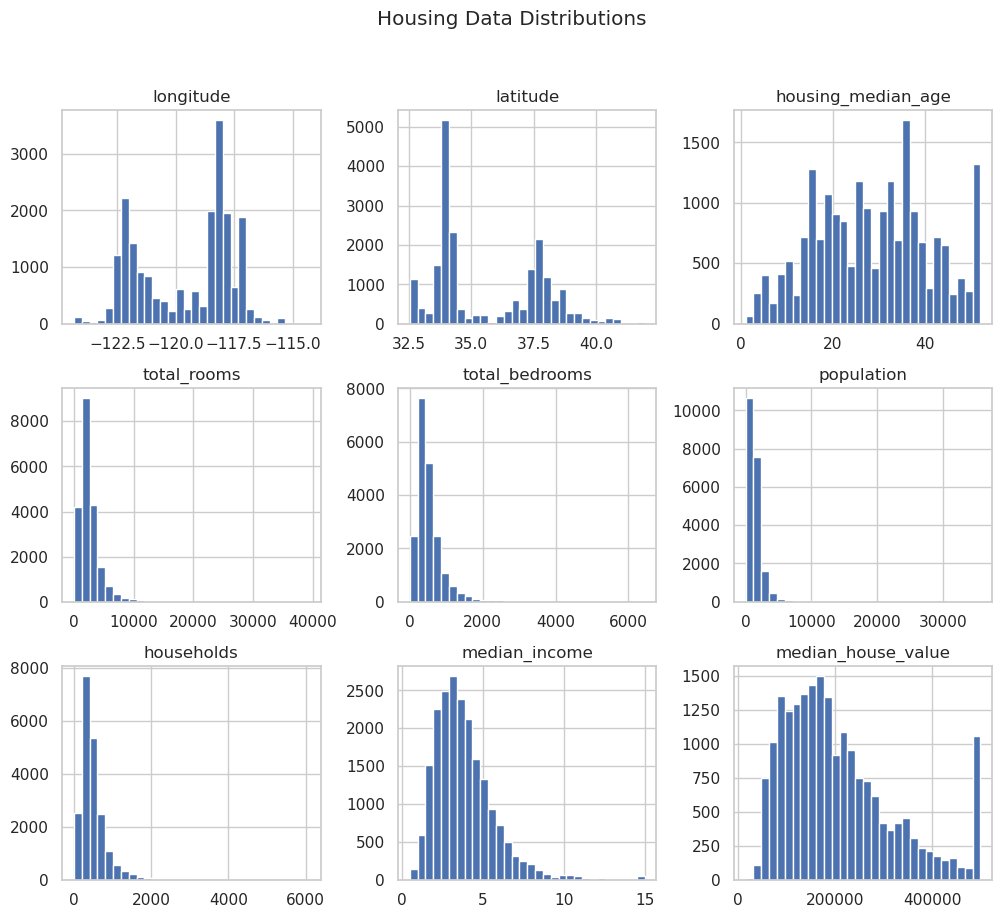

In [9]:
#Housing Histogram 
housing.hist(figsize=(12,10) , bins=30)
plt.suptitle("Housing Data Distributions")
plt.show()

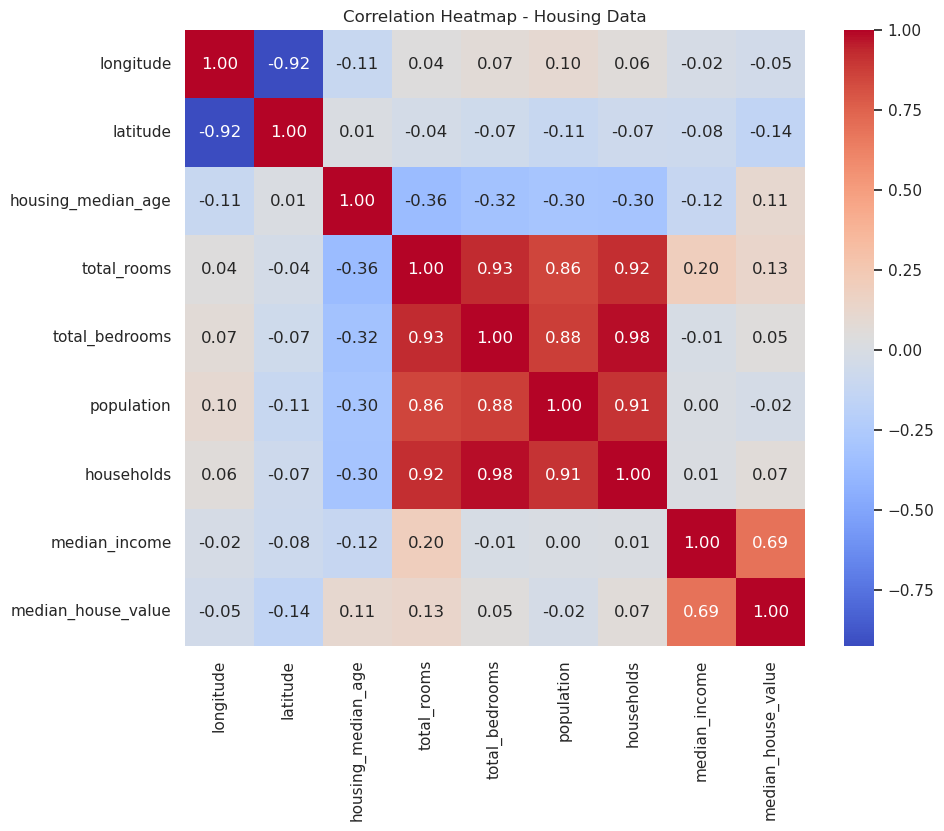

In [13]:
#Correlation Heat Map 
plt.figure(figsize=(10,8))
corr_housing = housing.corr(numeric_only = True)

sns.heatmap(corr_housing,annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap - Housing Data")
plt.show()

### Correlation Insights

- Median income shows a strong positive correlation with median house value.
- Features such as total_rooms and households show strong correlation with population related variables.
- Longitude and latitude show a strong negative linear correlations but are important for geographic patterns.

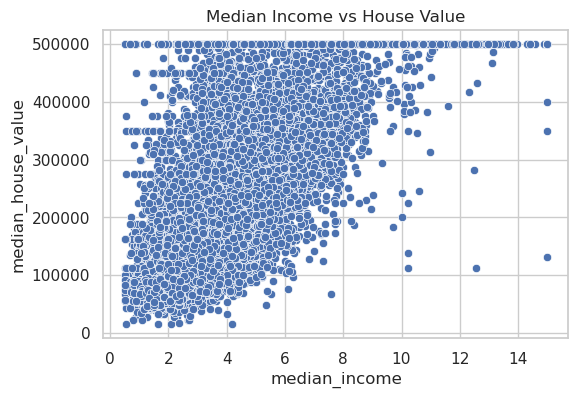

In [11]:
#Scatterplot of Median Income Vs Median House Value
plt.figure(figsize=(6,4))
sns.scatterplot(data=housing, x="median_income", y="median_house_value")
plt.title("Median Income vs House Value")
plt.show()

### Scatter Plot Observations (Median Income vs House Value)
- Strong positive relationship between median_income and median_house_value
- Higher income areas tend to have higher housing prices
- Data shows clear upward trend overall
- Noticeable clustering of values at the upper limit (~500,000)
- Indicates the target variable is capped
- Reduced variability at lower income levels
- Greater spread in house values at higher income levels
- median_income appears to be a strong predictor of housing price
- Some outliers exist at higher income levels with varying house values
- Relationship is not perfectly linear, suggesting influence from other features (location)

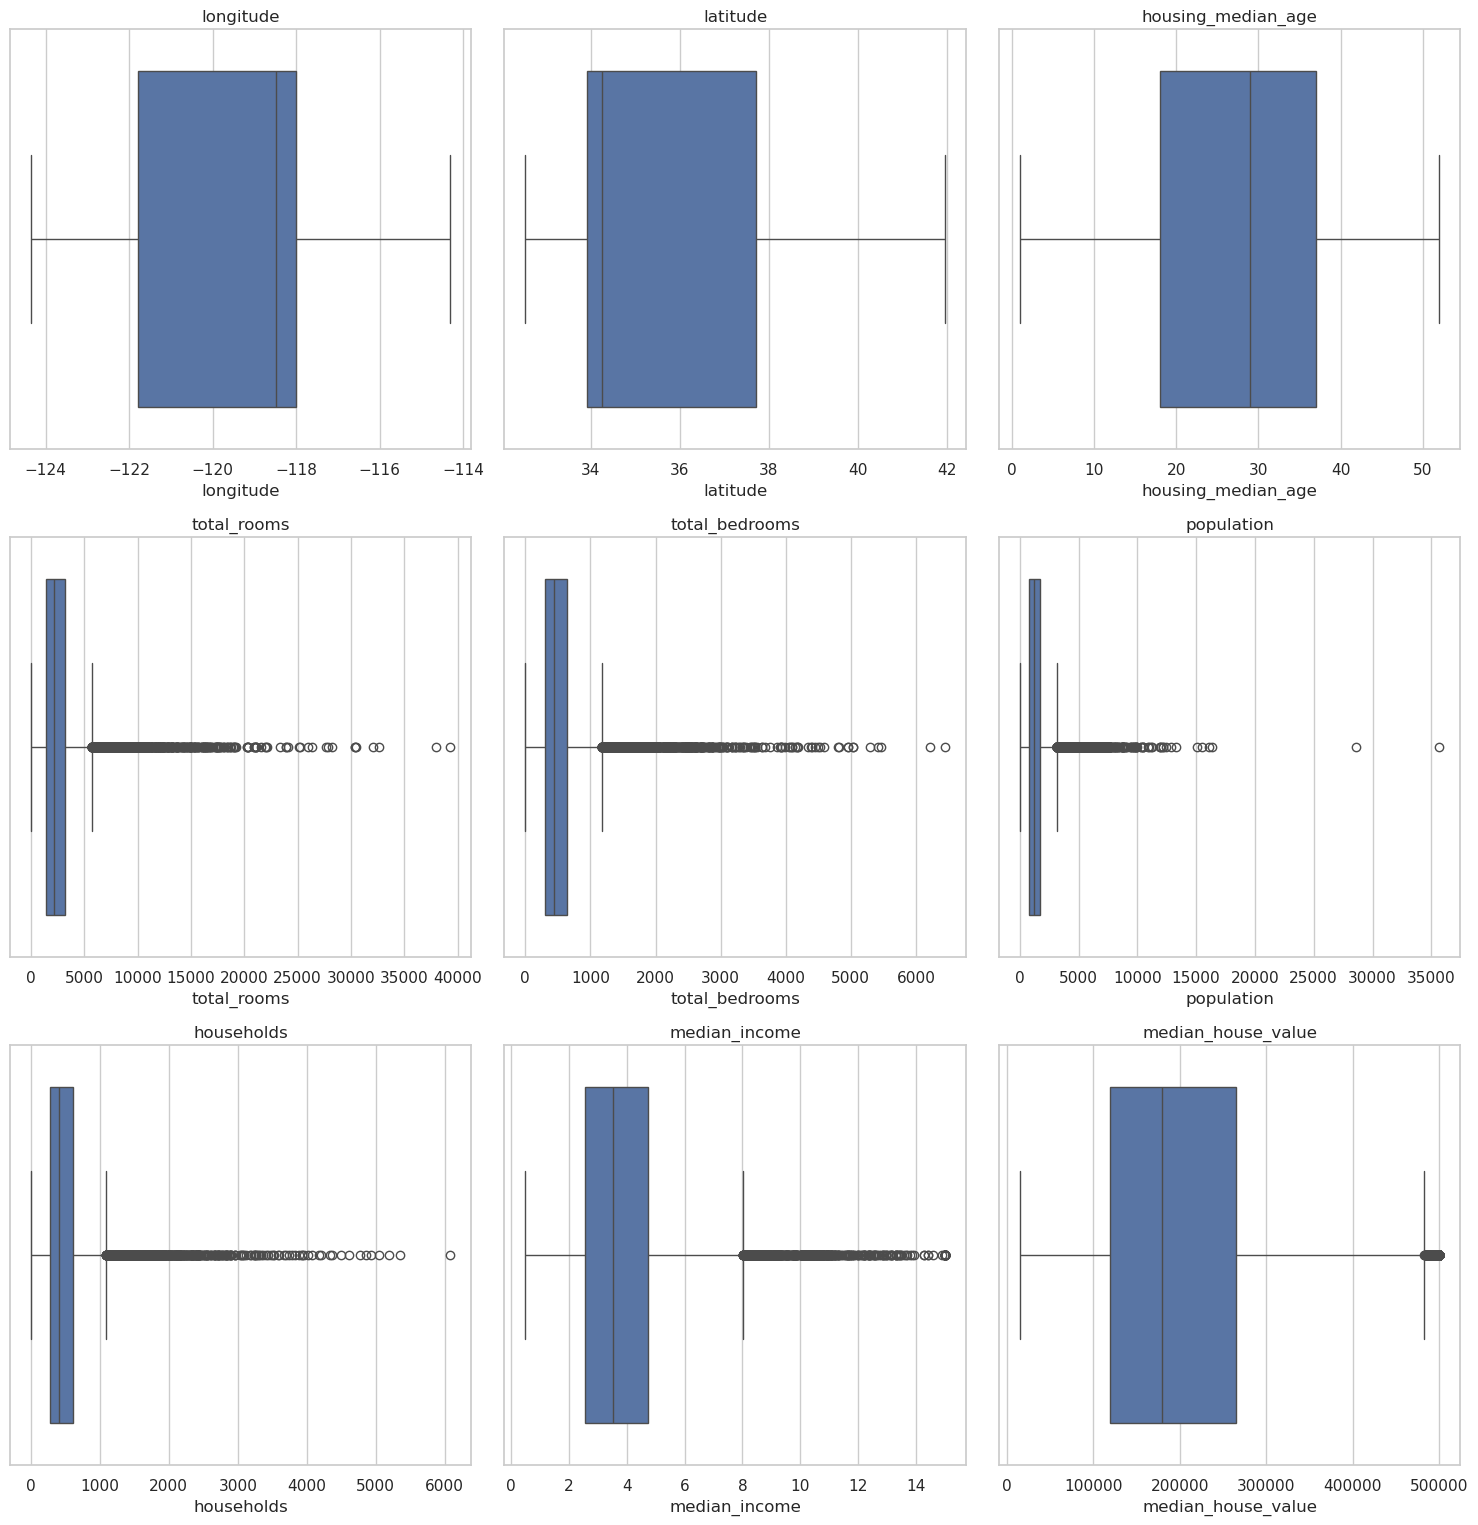

In [12]:
#Boxplot to Visualize Outlier
num_cols = housing.select_dtypes(include='number').columns

# Set grid size
cols = 3  # number of plots per row
rows = (len(num_cols) // cols) + 1

plt.figure(figsize=(15, 5 * rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(x=housing[col])
    plt.title(col)

plt.tight_layout()
plt.show()